# Signaling Analysis
### Analyzing the performance of the signaling apparatus

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [15]:
active_pairs = pd.read_csv("../data/manipulated/active_pairs.csv", parse_dates=True)

train_residuals = pd.read_csv("../data/manipulated/residuals_train.csv", index_col=0, parse_dates=True)

train_start = train_residuals.index.min()
train_end = train_residuals.index.max()

validation_residuals = pd.read_csv("../data/manipulated/residuals_val.csv", index_col=0, parse_dates=True)

val_start = validation_residuals.index.min()
val_end = validation_residuals.index.max()

test_residuals = pd.read_csv("../data/manipulated/residuals_test.csv", index_col=0, parse_dates=True)

test_start = test_residuals.index.min()
test_end = test_residuals.index.max()

In [16]:
def compute_match_percentage(df):
    # exclude rows where signal == 0
    df = df[df["signal"] != 0]

    # define match condition
    matches = (
        ((df["signal"] == 1) & (df["minhash_signal"] > 0)) |
        ((df["signal"] == -1) & (df["minhash_signal"] < 0))
    )

    return matches.mean()  # proportion

In [17]:
train_results = []
validation_results = []
test_results = []
full_results = []

for _, row in active_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    filename = f"../data/manipulated/spreads/{a}_{b}.csv"
    
    full = pd.read_csv(filename, index_col=0, parse_dates=True)
    train = full.loc[train_start:train_end]
    val = full.loc[val_start:val_end]
    test = full.loc[test_start:test_end]

    train_pct = compute_match_percentage(train)
    val_pct = compute_match_percentage(val)
    test_pct = compute_match_percentage(test)
    full_pct = compute_match_percentage(full)

    train_results.append(train_pct)
    validation_results.append(val_pct)
    test_results.append(test_pct)
    full_results.append(full_pct)

print("Train mean match %:", np.mean(train_results))
print("Validation mean match %:", np.mean(validation_results))
print("Test mean match %:", np.mean(test_results))
print("Full mean match %:", np.mean(full_results))

Train mean match %: 0.6919004857586326
Validation mean match %: 0.35786795204575633
Test mean match %: 0.34817503225376
Full mean match %: 0.6209399824789186


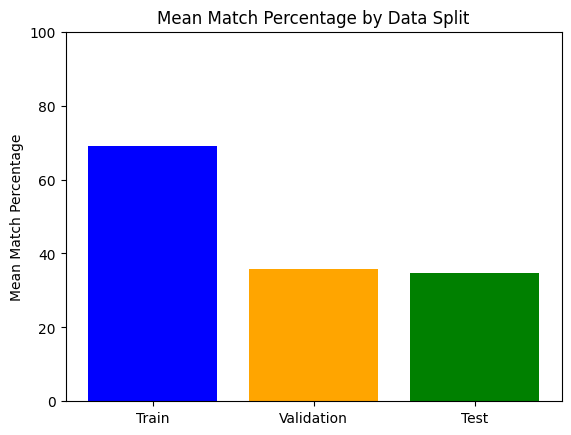

In [21]:
# plot match percentage for each split
splits = ['Train', 'Validation', 'Test']
means = np.array([np.mean(train_results), np.mean(validation_results), np.mean(test_results)])
plt.bar(splits, 100*means, color=['blue', 'orange', 'green'])
plt.ylabel('Mean Match Percentage')
plt.title('Mean Match Percentage by Data Split')
plt.ylim(0, 100)
plt.show()

In [22]:
results = []

for _, row in active_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    filename = f"../data/manipulated/spreads/{a}_{b}.csv"
    
    full = pd.read_csv(filename, index_col=0, parse_dates=True)
    train = full.loc[train_start:train_end]

    results.append({
        "pair": f"{a}_{b}",
        "train_match_pct": compute_match_percentage(train),
        "full_match_pct": compute_match_percentage(full)
    })

results_df = pd.DataFrame(results)
print(results_df)

          pair  train_match_pct  full_match_pct
0      ACN_MSI         0.689474        0.631356
1      CDW_HAS         0.744318        0.666667
2     CTSH_CSX         0.701087        0.639640
3     CTSH_ACN         0.680000        0.605263
4      CTSH_IT         0.693989        0.609756
..         ...              ...             ...
127    HAS_ACN         0.711864        0.638009
128    CRH_ACN         0.687500        0.625514
129    CRH_MSI         0.674419        0.614754
130   CBRE_MSI         0.660377        0.559028
131  CBRE_PAYX         0.681818        0.636086

[132 rows x 3 columns]


In [23]:
print(results_df["full_match_pct"].min())
print(results_df["full_match_pct"].max())

0.5277777777777778
0.7101449275362319
